In [9]:
import sympy as sp

def obtener_funcion():
    x = sp.symbols('x')
    while True:
        try:
            expresion = input("Ingrese la función en términos de x (por ejemplo, x^3-x-1): ")
            # Reemplazamos '^' por '**' para la notación de exponentes en Python
            expresion = expresion.replace("^", "**")
            # Convertimos la cadena de texto a una expresión simbólica
            f_simbolica = sp.sympify(expresion)
            # Usamos "numpy" para que la función retorne valores numéricos (flotantes)
            f_numerica = sp.lambdify(x, f_simbolica, "numpy")
            return f_numerica, f_simbolica
        except (sp.SympifyError, TypeError):
            print("Error: La función ingresada no es válida. Intente de nuevo.")

def obtener_intervalo():
    while True:
        try:
            a = float(input("Ingrese el valor de a (inicio del intervalo): "))
            b = float(input("Ingrese el valor de b (fin del intervalo): "))
            if a >= b:
                print("El valor de 'a' debe ser menor que 'b'. Intente de nuevo.")
                continue
            return a, b
        except ValueError:
            print("Error: Debe ingresar números válidos.")

def metodo_biseccion_auto(f, a, b, tol=1e-6, max_iter=100):
    midpoints = [] 
    for i in range(max_iter):
        c = (a + b) / 2  
        midpoints.append(c)
        
        # Calculamos el error usando (b - a)/2
        error = abs(b - a) / 2
        fc_val = float(f(c))
        
        print(f"Iteración {i+1}: c = {c:.8f}, error = {error:.8f}, f(c) = {fc_val:.8f}")
        
        # Usamos solo el ancho del intervalo para detener el algoritmo
        if error < tol:
            print("Condición de convergencia alcanzada por error en el intervalo.")
            return c, midpoints, i + 1
        
        fa_val = float(f(a))
        
        if fa_val * fc_val < 0:
            b = c
        else:
            a = c
            
    return c, midpoints, max_iter

            
    # Si se llega al máximo número de iteraciones, retornamos la última aproximación
    return c, midpoints, max_iter

# Bloque principal para ejecutar el código
if __name__ == "__main__":
    f_numerica, f_simbolica = obtener_funcion()
    a, b = obtener_intervalo()
    
    # Definimos una tolerancia (modificar este valor)
    tolerancia = 0.01
    
    raiz, midpoints, iteraciones = metodo_biseccion_auto(f_numerica, a, b, tol=tolerancia)
    print(f"\nAproximación de la raíz (Bisección): {raiz}")
    print(f"Se realizaron {iteraciones} iteraciones.")

Iteración 1: c = 1.50000000, error = 1.50000000, f(c) = 0.87500000
Iteración 2: c = 0.75000000, error = 0.75000000, f(c) = -1.32812500
Iteración 3: c = 1.12500000, error = 0.37500000, f(c) = -0.70117188
Iteración 4: c = 1.31250000, error = 0.18750000, f(c) = -0.05151367
Iteración 5: c = 1.40625000, error = 0.09375000, f(c) = 0.37466431
Iteración 6: c = 1.35937500, error = 0.04687500, f(c) = 0.15261459
Iteración 7: c = 1.33593750, error = 0.02343750, f(c) = 0.04834890
Iteración 8: c = 1.32421875, error = 0.01171875, f(c) = -0.00212795
Iteración 9: c = 1.33007812, error = 0.00585938, f(c) = 0.02297349
Condición de convergencia alcanzada por error en el intervalo.

Aproximación de la raíz (Bisección): 1.330078125
Se realizaron 9 iteraciones.


In [10]:
import sympy as sp

def obtener_funcion():
    x = sp.symbols('x')
    while True:
        try:
            expresion = input("Ingrese la función en términos de x (por ejemplo, x^3-x-1): ")
            # Reemplazamos '^' por '**' para la notación de exponentes en Python
            expresion = expresion.replace("^", "**")
            f_simbolica = sp.sympify(expresion)
            f_numerica = sp.lambdify(x, f_simbolica, "numpy")
            return f_numerica, f_simbolica
        except (sp.SympifyError, TypeError):
            print("Error: La función ingresada no es válida. Intente de nuevo.")

def obtener_intervalo():
    while True:
        try:
            a = float(input("Ingrese el valor de a (inicio del intervalo): "))
            b = float(input("Ingrese el valor de b (fin del intervalo): "))
            if a >= b:
                print("El valor de 'a' debe ser menor que 'b'. Intente de nuevo.")
                continue
            return a, b
        except ValueError:
            print("Error: Debe ingresar números válidos.")

def metodo_regla_falsa_auto(f, a, b, tol=1e-6, max_iter=100):
    aproximaciones = []
    prev_c = None
    for i in range(max_iter):
        # Calculamos c usando la fórmula de la regla falsa:
        # c = b - f(b)*(a - b) / (f(a) - f(b))
        c = b - (float(f(b)) * (a - b)) / (float(f(a)) - float(f(b)))
        aproximaciones.append(c)
        if prev_c is None:
            error = abs(b - a)
        else:
            error = abs(c - prev_c)
        
        fc_val = float(f(c))
        print(f"Iteración {i+1}: c = {c:.8f}, error = {error:.8f}, f(c) = {fc_val:.8f}")
        
        # Verificamos la condición de convergencia
        if error < tol or abs(fc_val) < tol:
            print("Condición de convergencia alcanzada.")
            return c, aproximaciones, i + 1
        
        # Actualizamos el intervalo según el signo de f en a y c
        if float(f(a)) * fc_val < 0:
            b = c
        else:
            a = c
        
        prev_c = c
        
    return c, aproximaciones, max_iter

# Bloque principal para ejecutar el código
if __name__ == "__main__":
    f_numerica, f_simbolica = obtener_funcion()
    a, b = obtener_intervalo()
    
    # Definimos una tolerancia (modificar este valor según se requiera)
    tolerancia = 0.01
    
    raiz, aproximaciones, iteraciones = metodo_regla_falsa_auto(f_numerica, a, b, tol=tolerancia)
    print(f"\nAproximación de la raíz (Regla Falsa): {raiz}")
    print(f"Se realizaron {iteraciones} iteraciones.")



Iteración 1: c = 0.12500000, error = 3.00000000, f(c) = -1.12304688
Iteración 2: c = 0.25884544, error = 0.13384544, f(c) = -1.24150254
Iteración 3: c = 0.39923073, error = 0.14038529, f(c) = -1.33559927
Iteración 4: c = 0.54196753, error = 0.14273680, f(c) = -1.38277606
Iteración 5: c = 0.68136545, error = 0.13939793, f(c) = -1.36503549
Iteración 6: c = 0.81126547, error = 0.12990001, f(c) = -1.27732975
Iteración 7: c = 0.92642376, error = 0.11515829, f(c) = -1.13131040
Iteración 8: c = 1.02363598, error = 0.09721222, f(c) = -0.95103886
Iteración 9: c = 1.10211270, error = 0.07847672, f(c) = -0.76342886
Iteración 10: c = 1.16308462, error = 0.06097192, f(c) = -0.58970348
Iteración 11: c = 1.20900446, error = 0.04591984, f(c) = -0.44181257
Iteración 12: c = 1.24275972, error = 0.03375525, f(c) = -0.32337735
Iteración 13: c = 1.26712376, error = 0.02436404, f(c) = -0.23262654
Iteración 14: c = 1.28447492, error = 0.01735116, f(c) = -0.16525083
Iteración 15: c = 1.29671273, error = 0.012

Iteración 1: c = 1.50000000, error = 1.50000000, f(c) = 0.87500000
Iteración 2: c = 0.75000000, error = 0.75000000, f(c) = -1.32812500
Iteración 3: c = 1.12500000, error = 0.37500000, f(c) = -0.70117188
Iteración 4: c = 1.31250000, error = 0.18750000, f(c) = -0.05151367
Iteración 5: c = 1.40625000, error = 0.09375000, f(c) = 0.37466431
Iteración 6: c = 1.35937500, error = 0.04687500, f(c) = 0.15261459
Iteración 7: c = 1.33593750, error = 0.02343750, f(c) = 0.04834890
Iteración 8: c = 1.32421875, error = 0.01171875, f(c) = -0.00212795
Iteración 9: c = 1.33007812, error = 0.00585938, f(c) = 0.02297349
Condición de convergencia alcanzada por error en el intervalo.
Iteración 1: c = 0.12500000, error = 3.00000000, f(c) = -1.12304688
Iteración 2: c = 0.25884544, error = 0.13384544, f(c) = -1.24150254
Iteración 3: c = 0.39923073, error = 0.14038529, f(c) = -1.33559927
Iteración 4: c = 0.54196753, error = 0.14273680, f(c) = -1.38277606
Iteración 5: c = 0.68136545, error = 0.13939793, f(c) = -1

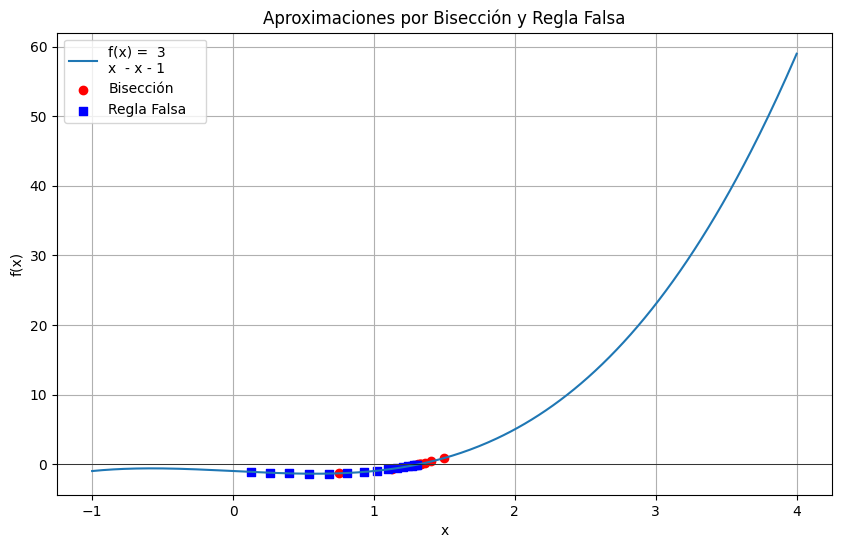

In [12]:
from matplotlib import pyplot as plt
import numpy as np


def plot_metodos(f, a, b, midpoints, aproximaciones, f_simbolica):
    x_vals = np.linspace(a - 1, b + 1, 400)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, label=f"f(x) = {sp.pretty(f_simbolica)}")
    plt.axhline(0, color='black', lw=0.5)
    
    plt.scatter(midpoints, f(np.array(midpoints)), color='red', marker='o', label="Bisección")
    plt.scatter(aproximaciones, f(np.array(aproximaciones)), color='blue', marker='s', label="Regla Falsa")
    
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Aproximaciones por Bisección y Regla Falsa")
    plt.legend()
    plt.grid(True)
    plt.show()

# Bloque principal: Se ingresan los datos
if __name__ == "__main__":
    f_numerica, f_simbolica = obtener_funcion()
    a, b = obtener_intervalo()
    tolerancia = 0.01
    
    # Ejecutamos ambos métodos
    raiz_b, midpoints, iter_b = metodo_biseccion_auto(f_numerica, a, b, tol=tolerancia)
    raiz_rf, aproximaciones, iter_rf = metodo_regla_falsa_auto(f_numerica, a, b, tol=tolerancia)
    
    print(f"\nAproximación de la raíz (Bisección): {raiz_b} en {iter_b} iteraciones.")
    print(f"Aproximación de la raíz (Regla Falsa): {raiz_rf} en {iter_rf} iteraciones.")
    
    # Se utiliza la misma función y el mismo intervalo para graficar los resultados de ambos métodos
    plot_metodos(f_numerica, a, b, midpoints, aproximaciones, f_simbolica)
